In [2]:
import tensorflow as tf

model = tf.keras.models.load_model("models_trained/xception_model.h5")

model

<Sequential name=sequential_2, built=True>

In [3]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [4]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\anany\AppData\Local\Temp\tmphlnlhqsn\assets


INFO:tensorflow:Assets written to: C:\Users\anany\AppData\Local\Temp\tmphlnlhqsn\assets


Saved artifact at 'C:\Users\anany\AppData\Local\Temp\tmphlnlhqsn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2399710530064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710530640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710532368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710531984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710530832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710532560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710531024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710532944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710531216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399710531792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2399

In [5]:
with open("models_trained/xception_quant.tflite", "wb") as f:
    f.write(tflite_model)

Test

In [6]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(model_path="models_trained/xception_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [7]:
print(input_details)

[{'name': 'serving_default_input_layer_4:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [8]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
interpreter = tf.lite.Interpreter(model_path="models_trained/xception_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_gen = test_datagen.flow_from_directory(
    "resized_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())

Found 195 images belonging to 3 classes.


In [12]:
correct = 0
total = 0

y_true = []
y_pred = []

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]

    for j in range(len(x_batch)):
        img = x_batch[j].astype(np.float32)
        img = np.expand_dims(img, axis=0)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        pred = np.argmax(output)
        true = np.argmax(y_batch[j])

        y_pred.append(pred)
        y_true.append(true)

        if pred == true:
            correct += 1
        total += 1

print("TFLite Accuracy:", correct / total)

TFLite Accuracy: 0.6615384615384615


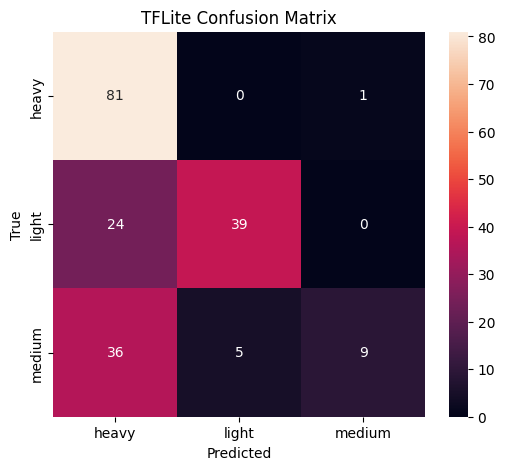

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TFLite Confusion Matrix")
plt.show()

In [14]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       heavy       0.57      0.99      0.73        82
       light       0.89      0.62      0.73        63
      medium       0.90      0.18      0.30        50

    accuracy                           0.66       195
   macro avg       0.79      0.60      0.59       195
weighted avg       0.76      0.66      0.62       195



let's see the original one